# Climate Change

The IPCC (Intergovernmental Panel on Climate Change) estimates that SE Asia will be one of the regions where climate change will be felt most overall (see the report – Climate Change 2014: Impacts, Adaptation and Vulnerability).

Mostly due to increase in temperature and temperature extremes.

Moreover, precipitation is expected to become more variable:

"In South Asia, the frequency of heavy precipitation events is increasing, while
light rain events are decreasing."

To adapt to climate change, stakeholders can use PalmSim to estimate the effect of climate change on oil palm.

In this demo we will estimate oil palm production in North Sumatra for past and future weather.

We will first consider the past. Then we (you) will consider the future weather for different levels of weather extremity. 

# Past Weather

Let us first import past weather data and calculate oil palm production.

*Note, this weather data is for demo purposes and is based on actual past weather data but not the actual past weather data.*

In [1]:
# to allow us to work with spreadsheets import the "pandas" library
import pandas as pd

# to allow us to make plots, import a plotting library
import matplotlib.pyplot as plt

# read-in the csv-file
weather_past = pd.read_csv('./input/north_sumatra.csv',index_col='Date')
weather_past.index = pd.to_datetime(weather_past.index)

What kind of trends and events do you observe?

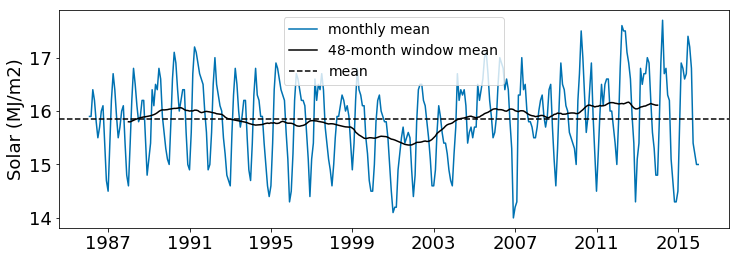

In [2]:
from plotting import tsplot, add_highlight

f,ax = tsplot(weather_past,'Solar (MJ/m2)',window=48)
ax.axhline(weather_past['Solar (MJ/m2)'].mean(),color='black',linestyle='--',label='mean')
ax.legend()

Disconsidering the dip in radiation in 2000 the weather seems to somehow have become a little bit more sunny.

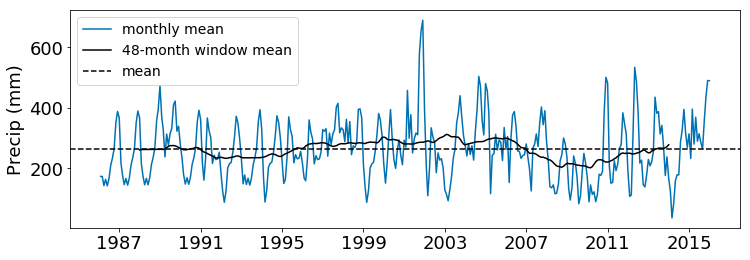

In [3]:
f,ax = tsplot(weather_past,'Precip (mm)',window=48)
ax.axhline(weather_past['Precip (mm)'].mean(),color='black',linestyle='--',label='mean')
ax.legend();

Overall the precipitation is ample for oil palm: on average around 280 mm per month with minima of around 100 mm per month.

For reference, evapotranspiration is little in comparison at around 150 mm per month.

However, it turns out that in the year 2008--2010 there were some relative dry spells and a short severe drought in 2014 which were most likely noticeably in oil palm.

**Based on the report by the IPCC we can assume that in the future dry spells will be more frequent and/or severe.**

# Past Production

Given the ample rainfall we expect little water stress due to soil water deficit.

Let us simulate a field of oil palm to calculate how exactly.

In [4]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from PalmField import PalmField

weather_data = weather_past

year_of_planting = weather_data.index.year[0]

# 1. Initialize the model
p = PalmField(year_of_planting=year_of_planting)

# 2. Couple the weather data:
p.weather.radiation_series = weather_data['Solar (MJ/m2)']
p.weather.rainfall_series = weather_data['Precip (mm)']

# 3. Run the model
df = p.run(duration=360,)

# copy results for later
df_past = df.copy()

### Past Soil Water Status

Naturally for crop production a good soil water status is crucial.

As expected, given this rainfall the precipitation is ample.

The water deficit is at at most around 150 mm.

Given a water holding capacity (WHC) of 600 mm for the whole rooted zone the soil operates around field capacity.

Note, a WHC of 600 mm is attained in for a rooting depth of 3 meters and a WHC of 200mm/m of the soil.

The soil moisture content (here defined as the ratio of available water to the WHC) is never below 80%.

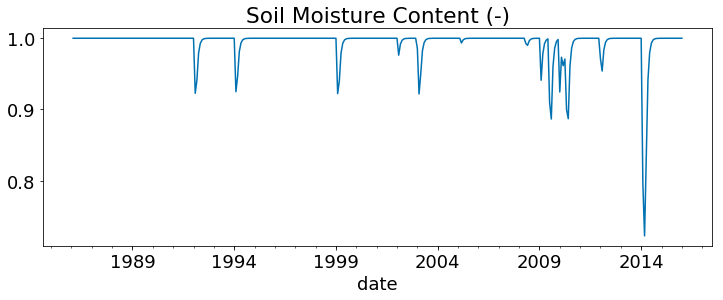

In [5]:
ax = df['soil moisture content (1)'].plot(figsize=(12,4))
ax.set_title('Soil Moisture Content (-)');

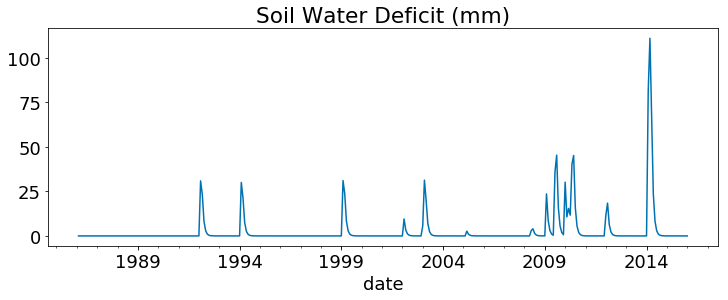

In [6]:
ax = df['soil water deficit (mm)'].plot(figsize=(12,4))
ax.set_title('Soil Water Deficit (mm)');

### Past Production

Since there is ample water the production may reach the potential production.

For this site this is around 40 tonnes of FFB per year!

Note, fluctuations due to fluctuations in solar radiation.

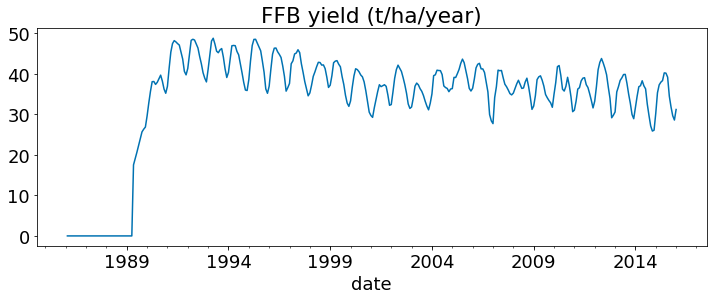

In [7]:
ax = df['organs yield FM yearly (tonne FM/year)'].plot(figsize=(12,4))
ax.set_title('FFB yield (t/ha/year)');

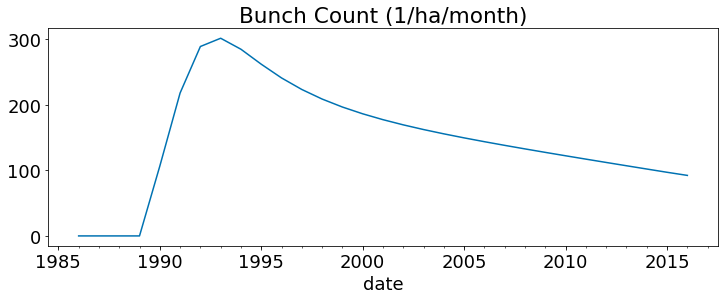

In [8]:
ax = df['organs bunch count (1/ha/month)'].resample('12M').mean().plot(figsize=(12,4))
ax.set_title('Bunch Count (1/ha/month)');

# Weather

As an estimate for the future weather, **let us assume that the variability of precipitation will increase**.

That is to say, where for the **past weather we had a mean precipitation** of around 260 mm/month and extremes arpound 100 to 400 mm/momth:

In [ ]:
# let us view some summary statistics
weather_past['Precip (mm)'].describe()

In [ ]:
# let us view the histogram
weather_past['Precip (mm)'].plot(kind='hist',bins=20,color='black');

In [ ]:
# let us view the time-series
ax = weather_past['Precip (mm)'].plot(figsize=(12,4))
ax.set_ylabel('Precip (mm/month)');

### Future scenario definition

Let us consider the following hypothetical future weather scenario:

Let us assume that the mean precipitation in the future is equal to that of the past. But that however, the extremes will be more severe:

More extreme **dry spells with 0 mm/month and months of extreme rainfall with over 500 mm/month.**

Let us make such a scenario based on the past weather.

In [ ]:
# technical detail, we will scale the weather time-series
# relative to the mean
# starting at a scaling of 1 (identical to past)
# ending with a scaling > 1 e.g. 1.5, 1.5 times more extreme than past

weather_future = weather_past.copy()
weather_future.index += pd.DateOffset(years=30)

import numpy as np

severity_index_t0 = 1
severity_index_t1 = 1.8

def scale(x,a0=1,a1=1):
    ''' Scale a time-series away from its mean.
    
    a0: The scaling for the start of the series.
    a1: The scaling for the end of the series.
    '''
    a = np.linspace(a0,a1,len(x))
    return a*(x-x.mean())+x.mean()

weather_future['Precip (mm)'] = scale(weather_future['Precip (mm)'],
                                      severity_index_t0,
                                      severity_index_t1)

mask = weather_future['Precip (mm)'] < 0
weather_future.loc[mask,'Precip (mm)'] = 0

Now that we have created the hypothetical future weather let us do the following,

**Let us view the properties of the hypothetical future precipitation:**

In [ ]:
# let us view the summary statistics
weather_future['Precip (mm)'].describe()

Note, there are now extremely dry months with verly little rain.

In [ ]:
weather_future['Precip (mm)'].plot(kind='hist',bins=20,color='black');

In [ ]:
ax = weather_future['Precip (mm)'].plot(figsize=(12,6))
weather_past['Precip (mm)'].plot(ax=ax)
ax.grid()
ax.set_ylabel('Precip (mm/month)');

As climate change develops the chance of a number of consecutive severe dry spells increases.

Here, **the dry spells around 2040 will most likely affect oil palm production due to water deficit.**

# Future Production

In [ ]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from PalmField import PalmField

weather_data = weather_future

year_of_planting = weather_data.index.year[0]

# 1. Initialize the model
p = PalmField(year_of_planting=year_of_planting)

# 2. Couple the weather data:
p.weather.radiation_series = weather_data['Solar (MJ/m2)']
p.weather.rainfall_series = weather_data['Precip (mm)']

# 3. Run the model
df = p.run(duration=360,)

# copy results for later
df_future = df.copy()

### Future Soil Water Status

The increased severity of the dry spells results in periodic critical water deficits and low soil moisture contents.

In [ ]:
ax = df['soil moisture content (1)'].plot(figsize=(12,4))
ax.set_title('Soil Moisture Content (-)');

In [ ]:
ax = df['soil water deficit (mm)'].plot(figsize=(12,4))
ax.set_title('Soil Water Deficit (mm)');

These deficits will definitely limit production.

### Future Production

For the first few years in our scenario the oil palms produce at a potential rate.

However as weather becomes more severe the production will become water-limited due to a reduction of photosynthesis (stomatal closure) and bunch counts (low sex ratio, abortion).

In this hypothetical scenario the yield drops from 40 tonnes FFB/ha/year to a low 10 tonnes around 2040!

Irrigation might be considered to combat the drought.

In [ ]:
ax = df['yield FM yearly (tonne FM/year)'].plot(figsize=(12,4))
ax.set_title('FFB yield (t/ha/year)');

In [ ]:
ax = df['organs bunch count (1/ha/month)'].plot(figsize=(12,4))
ax.set_title('Bunch Count (1/ha/month)');

We see dips in bunch count (1/ha/month) related to dips in the female fraction and increased inflorescence abortion.

In [ ]:
ax = df['organs female fraction (1)'].plot(figsize=(12,4))
ax.set_title('Sex Ratio (-)');

In [ ]:
ax = df['organs inflorescence abortion fraction (1)'].plot(figsize=(12,4))
ax.set_title('Inflorescence abortion (1/month)')

# Comparison

Now let us simply compare past and future:

In [ ]:
column = 'organs yield FM yearly (tonne FM/year)'
f,ax = tsplot(df_past,column,figsize=(14,6))
f,ax = tsplot(df_future,column,ax=ax)
ax.set_title('FFB yield (t/ha/year)');

## Important note

Although this example shows possible implications of climate change the considered future weathe is hypothetical. Real climate scenarios are best estimated by climate people.

In any case, oil palm production world wide (definitely nearby) would be similarly effected.

Still, much value (profit) can be saved by being able to predict risk/yield in advance.